# Task-Specific Examples with a Large Language Model

**Who this is for:** Master's students in Digital Humanities. No programming or AI background is needed.

**What you will do:** use one language model (Google's Gemini, which has a free tier) to perform five common research tasks on historical and archival text, in English and Arabic:

1. Translation
2. Summarisation
3. Sentiment analysis
4. Named entity recognition (finding people, places, dates...)
5. Relationship extraction (finding who did what, where and when)

Every task follows the same recipe: **a clear instruction + your text + the output format you want**.

## How to use this notebook

- A notebook is made of **cells**. Grey cells contain Python code; white cells contain explanations.
- To run a code cell, click it and press the **play button** on its left (or press `Shift+Enter`). Run the cells **from top to bottom**.
- Lines that start with `#` are **comments**: notes for humans that Python ignores. Read them. They explain what each line does.
- You do not need to change any code to get results. Where you *may* want to change something (for example your own text), the comments say so.

## Step 0: Get a free API key (one-time setup)

The model runs on Google's servers. To use it from this notebook you need a personal **API key**, a long secret password that identifies your account. Google offers a **free tier**, so you do not need a payment card.

1. Go to **aistudio.google.com** and sign in with a Google account.
2. Click **Get API key**, create a key, and copy it.
3. In Colab, click the **key icon** in the left sidebar, choose *Add new secret*, and enter:
   - **Name:** `GEMINI_API_KEY`
   - **Value:** the key you copied
   - Switch on **Notebook access**.

**Never paste your key directly into a cell or share it.**

**Two things to know about the free tier**
- **Privacy:** on the free tier, Google may use what you send to improve its products, and people may review it. Use only **public or non-sensitive texts**. Never send private, restricted or unpublished material.
- **Limits:** the free tier allows only a limited number of requests per minute and per day. If you hit a limit, the notebook waits and tries again automatically. If it keeps failing, wait a few minutes (or until the next day) and run the cell again.

## Step 1: Install and connect

In [ ]:
# Install the library that lets Python talk to Gemini.
# The "!" tells Colab to run this line as a system command; "-q" keeps the output short.
!pip install -q google-genai pandas networkx matplotlib

In [ ]:
import os                       # tools for reading settings from the computer
import json                     # tools for reading JSON (a simple, structured text format)
import time                     # lets us pause the program (used to wait when the free limit is reached)
from getpass import getpass     # asks the user to type text without showing it on screen
import pandas as pd             # pandas displays data as tables
from google import genai        # the library for Gemini
from google.genai import types  # extra tools for choosing settings

def get_key(name):
    """Return the API key called `name`, or ask the user to type it."""
    try:
        # Colab's secret storage (the key icon in the sidebar)
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        # Fallback if the secret is missing or we are not in Colab:
        # check the computer's settings, otherwise ask for the key (hidden while typing)
        return os.environ.get(name) or getpass(f"Enter {name}: ")

# Create the connection ("client") that we will use for every request
client = genai.Client(api_key=get_key("GEMINI_API_KEY"))

# The model we will use throughout. Model names change often and old ones are retired.
# If you get a "model not found" error, run the next cell and paste a current name here.
MODEL = "gemini-3-flash-preview"

print("Connected.")

Enter GEMINI_API_KEY: ··········
Connected.


### If the model name gives an error

Run the next cell to see which "flash" models (fast and free-tier friendly) are currently available to your key. Copy one name into `MODEL` in the cell above, run that cell again, and continue.

In [ ]:
# Ask Google for the list of models available to our key
for model in client.models.list():
    name = model.name.replace("models/", "")      # remove the "models/" prefix for readability
    if "gemini" in name and "flash" in name:      # keep only Gemini "flash" models
        print(name)

gemini-2.5-flash
gemini-2.5-flash-preview-tts
gemini-flash-latest
gemini-flash-lite-latest
gemini-2.5-flash-lite
gemini-2.5-flash-image
gemini-3-flash-preview
gemini-3.1-flash-lite-preview
gemini-3.1-flash-lite
gemini-3.1-flash-image-preview
gemini-3.1-flash-image
gemini-3.1-flash-lite-image
gemini-3.5-flash
gemini-3.5-flash-lite
gemini-omni-flash-preview
gemini-omni-1.1-flash
gemini-3.6-flash
gemini-3.7-flash
gemini-3.8-flash
gemini-3.1-flash-tts-preview
gemini-3.8-flash-tts
gemini-3.8-flash-lite-tts
gemini-2.5-flash-native-audio-latest
gemini-2.5-flash-native-audio-preview-09-2025
gemini-2.5-flash-native-audio-preview-12-2025
gemini-3.1-flash-live-preview


### Our helper function: `ask()`

Instead of repeating technical code in every task, we write it **once** in a function called `ask()`. A function is a reusable mini-program. You give it a **prompt** (your instruction and text) and it returns the model's **answer**.

Two details:
- For tasks where we want a table (sentiment, entities, relationships), `ask()` can switch on **JSON mode**, which makes the model reply in a strict, machine-readable format.
- We leave the *temperature* (randomness) setting at its default, as Google recommends for Gemini 3 models. Repeating a request may therefore give slightly different wording each time.

You do not need to understand how the function works inside, but the comments explain each part.

In [ ]:
# Standing instructions that apply to every request (called the "system instruction").
SYSTEM = ("You are a careful assistant for digital humanities researchers. "
          "Follow the requested output format exactly. Do not add comments outside the requested format.")

def ask(prompt, system=SYSTEM, json_mode=False, max_tokens=4000):
    """Send `prompt` to Gemini and return its answer as plain text.
    If json_mode is True, the model is told to answer in JSON."""

    # Collect the settings for this request in one object
    config = types.GenerateContentConfig(
        system_instruction=system,        # standing instructions
        max_output_tokens=max_tokens,     # maximum length (also covers the model's hidden "thinking")
        # In JSON mode the answer must be valid JSON; otherwise ordinary text
        response_mime_type="application/json" if json_mode else "text/plain",
    )

    # Try up to 5 times: free tiers sometimes say "too many requests" or "busy"
    for attempt in range(5):
        try:
            response = client.models.generate_content(
                model=MODEL,              # which model answers
                contents=prompt,          # our question
                config=config,            # the settings above
            )
            text = response.text          # the answer text
            if not text:                  # an empty answer is treated as an error
                raise ValueError("The model returned an empty answer. Run the cell again.")
            return text
        except Exception as error:
            message = str(error)
            # Codes 429 and 503 (and these words) mean "limit reached" or "service busy"
            busy = any(word in message for word in ["429", "503", "RESOURCE_EXHAUSTED", "UNAVAILABLE"])
            if busy and attempt < 4:
                wait = 20 * (attempt + 1)  # wait 20, 40, 60... seconds before trying again
                print(f"Free limit reached or service busy. Waiting {wait} seconds...")
                time.sleep(wait)
            else:
                raise                      # any other problem: show the error

# A quick test: the answer should be the single word "ready"
print(ask("Reply with the single word: ready"))

ready


### A second helper: reading structured answers

For some tasks (sentiment, entities, relationships) we want the answer as a **table**, not a paragraph. We ask the model to reply in **JSON**, a simple format that looks like this:

`{"name": "Ibn Battuta", "type": "PERSON"}`

The function `parse_json()` converts that text into Python data that we can show as a table.

In [ ]:
def parse_json(raw):
    """Turn the model's JSON text into Python data (lists and dictionaries)."""
    cleaned = raw.strip()
    # Models sometimes add a sentence or code fences (```json ... ```) around the JSON.
    # We find where the real JSON starts: the first "[" (a list) or "{" (a single record).
    starts = [i for i in (cleaned.find("["), cleaned.find("{")) if i != -1]
    if not starts:
        raise ValueError("No JSON found in the answer:\n" + raw)
    start = min(starts)
    # ...and where it ends: the last "]" or "}"
    end = max(cleaned.rfind("]"), cleaned.rfind("}")) + 1
    # Keep only that part and convert it
    return json.loads(cleaned[start:end])

## Our sample texts

We define two short texts once and reuse them in the tasks below. They are about two famous medieval authors, one in English and one in Arabic.

**Replace them with passages from your own research** to try the tasks on your material. Put your text between the quotation marks.

In [ ]:
# An English passage about the traveller Ibn Battuta.
# The parentheses let us write one long text over several lines.
english_text = (
    "In 1325, Ibn Battuta left Tangier to perform the pilgrimage to Mecca. He then travelled "
    "through Cairo, Damascus and Baghdad. Years later he served as a judge in Delhi under "
    "Sultan Muhammad bin Tughluq, before returning to Morocco, where he dictated his travel "
    "account to the scholar Ibn Juzayy."
)

# An Arabic passage about the historian Ibn Khaldun.
arabic_text = (
    "ولد ابن خلدون في تونس عام 1332 وكتب كتاب المقدمة. عمل في فاس وغرناطة، ثم استقر في القاهرة "
    "حيث درّس في الأزهر وتولى منصب قاضي القضاة. توفي عام 1406."
)

print(english_text)
print()
print(arabic_text)

In 1325, Ibn Battuta left Tangier to perform the pilgrimage to Mecca. He then travelled through Cairo, Damascus and Baghdad. Years later he served as a judge in Delhi under Sultan Muhammad bin Tughluq, before returning to Morocco, where he dictated his travel account to the scholar Ibn Juzayy.

ولد ابن خلدون في تونس عام 1332 وكتب كتاب المقدمة. عمل في فاس وغرناطة، ثم استقر في القاهرة حيث درّس في الأزهر وتولى منصب قاضي القضاة. توفي عام 1406.


---
## Task 1: Translation

Large language models translate well, and unlike older tools you can **give instructions** about style and about what to keep unchanged, such as personal names or technical terms.

In [ ]:
# Build the prompt by joining our instruction and the text with "+".
# "\n" means "start a new line".
prompt = (
    "Translate the following Arabic text into clear academic English.\n"
    "Keep personal and place names in their common English spelling.\n"
    "Return only the translation.\n\n"
    "Text: " + arabic_text
)

# Send the prompt and print the answer
print(ask(prompt))

Ibn Khaldun was born in Tunis in 1332 and authored the Muqaddimah. He worked in Fez and Granada before settling in Cairo, where he taught at al-Azhar and held the position of Chief Judge. He died in 1406.


In [ ]:
# The other direction: English to Modern Standard Arabic
prompt = (
    "Translate the following English text into Modern Standard Arabic.\n"
    "Return only the translation.\n\n"
    "Text: " + english_text
)
print(ask(prompt))

في عام ١٣٢٥، غادر ابن بطوطة طنجة لأداء فريضة الحج في مكة. ثم سافر عبر القاهرة ودمشق وبغداد. وبعد سنوات، عمل قاضيًا في دلهي في عهد السلطان محمد بن تغلق، قبل أن يعود إلى المغرب، حيث أملى مذكرات رحلته على العالم ابن جزي.


**Instructions change the result.** The next cell translates one Arabic proverb twice: once word by word, once naturally. A *literal* translation is useful when you want to study the structure of the source text; an *idiomatic* one reads better in a publication.

In [ ]:
proverb = "العلم نور والجهل ظلام"      # "Knowledge is light and ignorance is darkness"

# Two different instructions for the same text
styles = ["a literal, word-for-word translation", "a natural, idiomatic translation"]

for style in styles:                    # repeat the steps below once per style
    # f"..." lets us insert the variables {style} and {proverb} inside the text
    prompt = f"Translate this Arabic proverb into English as {style}. Return only the translation.\n\n{proverb}"
    print(f"{style}:")
    print("  ", ask(prompt))
    print()

a literal, word-for-word translation:
   Knowledge light and ignorance darkness.

a natural, idiomatic translation:
   Knowledge is light, and ignorance is darkness.



**Research tips**
- State the **target variety** (for example Modern Standard Arabic or a specific dialect) and the **audience**.
- For poetry, dialects and historical language, ask a speaker to check the output. Models are weaker there.

---
## Task 2: Summarisation

You can control the **length**, the **audience** and the **focus** of a summary. We use an invented description of a newspaper digitisation project, the kind of text you might meet in a project report.

In [ ]:
# An invented project description (for demonstration only)
long_text = (
    "Between 2018 and 2022 the National Library digitised forty thousand pages of local "
    "newspapers published between 1880 and 1920. The pages were scanned and processed with "
    "optical character recognition (OCR), but the typeface of the older issues caused many "
    "errors, so about a fifth of the words in the earliest years are misread. Volunteers "
    "corrected a sample of ten thousand pages, and these corrected pages were later used to "
    "improve the OCR software. The collection is now searchable online, although the library "
    "warns that searches may miss articles in the poorest-quality scans. Researchers have "
    "already used the collection to study how reports of strikes and epidemics changed over "
    "the period."
)

# Three instructions that ask for three different kinds of summary
instructions = [
    "Summarise in one sentence.",
    "Summarise in 3 bullet points for a general audience.",
    "Summarise in two sentences, focusing only on the limitations of the collection.",
]

for instruction in instructions:
    print("###", instruction)
    # Instruction first, then the text to work on
    print(ask(instruction + "\n\nText: " + long_text))
    print()

### Summarise in one sentence.
The National Library digitized forty thousand pages of local newspapers from 1880–1920, utilizing volunteer corrections to improve OCR accuracy and provide a searchable online resource already being used for historical research.

### Summarise in 3 bullet points for a general audience.
• The National Library digitised 40,000 pages of local newspapers from 1880 to 1920, making this historical collection searchable online for the first time.
• To improve accuracy, volunteers corrected 10,000 pages where the software struggled with old typefaces, helping to refine the digital text for better search results.
• Researchers are already using the archive to track historical changes in how major events, such as strikes and epidemics, were reported to the public.

### Summarise in two sentences, focusing only on the limitations of the collection.
Approximately twenty percent of the words in the earliest newspapers are misread due to OCR errors caused by historical

In [ ]:
# Summarise the Arabic text, and ask for the summary in Arabic
# (the instruction itself is written in Arabic: "Summarise the following text in one sentence in Arabic")
print(ask("لخّص النص التالي في جملة واحدة باللغة العربية:\n\n" + arabic_text))

يُعد ابن خلدون، مؤلف كتاب "المقدمة"، من أبرز المفكرين الذين تنوعت مسيرتهم بين تونس والمغرب والأندلس قبل أن يستقر في القاهرة مدرساً وقاضياً حتى وفاته عام 1406م.


**Research tip:** a summary can leave out or distort details. Keep the original text and spot-check summaries against it.

---
## Task 3: Sentiment analysis

*Sentiment analysis* labels the attitude in a text (positive, negative...). In Digital Humanities it is used, for example, on reader comments, reviews, letters or newspaper articles.

We ask for a **label** and a **short reason**, returned as JSON so we can put the results in a table. The texts below are Arabic comments that readers might leave about a digital archive (invented for this exercise).

In [ ]:
# Four invented reader comments about a digital archive
comments = [
    "الأرشيف الرقمي ساعدني كثيرا في بحثي",             # "The digital archive helped my research a lot"
    "البحث في الموقع بطيء والنتائج غير دقيقة",           # "Searching the site is slow and the results are inaccurate"
    "تم رفع المخطوطات الجديدة يوم الأحد",               # "The new manuscripts were uploaded on Sunday"
    "المخطوطات نادرة ومهمة لكن جودة الصور ضعيفة",       # "The manuscripts are rare and important but the image quality is poor"
]

def classify_sentiment(text):
    """Ask the model for the sentiment of one text and return it as a Python dictionary."""
    prompt = (
        "Classify the sentiment of the text as POSITIVE, NEGATIVE, NEUTRAL or MIXED.\n"
        "Return ONLY valid JSON with the keys \"sentiment\" and \"reason\" "
        "(the reason in one short English sentence).\n\n"
        "Text: " + text
    )
    return parse_json(ask(prompt, json_mode=True))

# Go through the comments one by one and collect one row per comment
rows = []
for comment in comments:
    result = classify_sentiment(comment)    # e.g. {"sentiment": "POSITIVE", "reason": "..."}
    row = {"text": comment}                 # start the row with the original text
    row.update(result)                      # add the sentiment and the reason
    rows.append(row)

# Show all rows as a table
df_sentiment = pd.DataFrame(rows)
df_sentiment

Free limit reached or service busy. Waiting 20 seconds...


,text,sentiment,reason
0,الأرشيف الرقمي ساعدني كثيرا في بحثي,POSITIVE,The text expresses a positive experience and b...
1,البحث في الموقع بطيء والنتائج غير دقيقة,NEGATIVE,The user expresses dissatisfaction with both t...
2,تم رفع المخطوطات الجديدة يوم الأحد,NEUTRAL,The text is a factual statement reporting an a...
3,المخطوطات نادرة ومهمة لكن جودة الصور ضعيفة,MIXED,The text praises the rarity and importance of ...


In [ ]:
# Count how many comments received each label
df_sentiment["sentiment"].value_counts()

,count
sentiment,
POSITIVE,1
NEGATIVE,1
NEUTRAL,1
MIXED,1


**Research tips**
- Define the labels that make sense for **your** corpus (for example add `SARCASTIC` or `IRONIC`).
- Sentiment in literary, historical or dialectal text is difficult. Label a sample by hand and compare it with the model's labels before trusting results at scale.

---
## Task 4: Named entity recognition (NER)

*Named entity recognition* finds the **names of people, places, organisations, dates** and similar items in a text. It is one of the most common first steps in Digital Humanities projects: it lets you build indexes, maps and timelines from large collections.

With a language model you simply **list the entity types** you want.

In [ ]:
def extract_entities(text):
    """Ask the model to list the named entities in `text` and return them as a list."""
    prompt = (
        "Extract named entities from the text.\n"
        "Allowed types: PERSON, PLACE, ORGANIZATION, DATE, WORK (title of a book or document).\n"
        "Return ONLY valid JSON: a list of objects with the keys \"text\" (exactly as written in the input) "
        "and \"type\". Do not invent entities that are not in the text.\n\n"
        "Text: " + text
    )
    return parse_json(ask(prompt, json_mode=True))

# Run it on the English text and show the result as a table
entities_en = extract_entities(english_text)
pd.DataFrame(entities_en)

,text,type
0,1325,DATE
1,Ibn Battuta,PERSON
2,Tangier,PLACE
3,Mecca,PLACE
4,Cairo,PLACE
5,Damascus,PLACE
6,Baghdad,PLACE
7,Delhi,PLACE
8,Muhammad bin Tughluq,PERSON
9,Morocco,PLACE


In [ ]:
# The same function works on the Arabic text, with no change
entities_ar = extract_entities(arabic_text)
pd.DataFrame(entities_ar)

,text,type
0,ابن خلدون,PERSON
1,تونس,PLACE
2,1332,DATE
3,المقدمة,WORK
4,فاس,PLACE
5,غرناطة,PLACE
6,القاهرة,PLACE
7,الأزهر,ORGANIZATION
8,1406,DATE


Notice that the Arabic entities are returned **exactly as written** in the text. That makes it easy to find them again in your corpus.

**Research tips**
- Always ask for the entity *as written* so that you can locate it in the source.
- Add your own rules to the prompt, for example: "Treat titles like *Sultan* as part of the person's name."
- Compare the model with a small, manually annotated sample before using it on a whole collection.

---
## Task 5: Relationship extraction

Knowing *who* and *where* is not enough: we often want to know **who did what to whom**. We ask for **triples** of the form *(subject, relation, object)*, for example *(Ibn Khaldun, born_in, Tunis)*. Triples can be stored in a table or database, or drawn as a network, which is the basis of a *knowledge graph*.

In [ ]:
def extract_relations(text):
    """Ask the model for (subject, relation, object) triples found in `text`."""
    prompt = (
        "Extract relationships between entities in the text as triples.\n"
        "Return ONLY valid JSON: a list of objects with the keys \"subject\", \"relation\", \"object\".\n"
        "Use short relation labels such as travelled_to, served_as, worked_in, born_in, wrote, taught_at, "
        "dictated_to, died_in_year. Only include relationships that are stated in the text. "
        "Write entity names in English.\n\n"
        "Text: " + text
    )
    return parse_json(ask(prompt, json_mode=True))

# English text: show the triples as a table
relations_en = extract_relations(english_text)
df_rel_en = pd.DataFrame(relations_en)
df_rel_en

,subject,relation,object
0,Ibn Battuta,travelled_to,Mecca
1,Ibn Battuta,travelled_to,Cairo
2,Ibn Battuta,travelled_to,Damascus
3,Ibn Battuta,travelled_to,Baghdad
4,Ibn Battuta,served_as,judge
5,Ibn Battuta,worked_in,Delhi
6,Ibn Battuta,worked_for,Muhammad bin Tughluq
7,Ibn Battuta,travelled_to,Morocco
8,Ibn Battuta,dictated_to,Ibn Juzayy


In [ ]:
# Arabic text: the answer is written in English, as the prompt requested
relations_ar = extract_relations(arabic_text)
pd.DataFrame(relations_ar)

,subject,relation,object
0,Ibn Khaldun,born_in,Tunis
1,Ibn Khaldun,born_in_year,1332
2,Ibn Khaldun,wrote,Al-Muqaddimah
3,Ibn Khaldun,worked_in,Fez
4,Ibn Khaldun,worked_in,Granada
5,Ibn Khaldun,travelled_to,Cairo
6,Ibn Khaldun,taught_at,Al-Azhar
7,Ibn Khaldun,served_as,Chief Judge
8,Ibn Khaldun,died_in_year,1406


### Draw the relationships as a network

Each triple becomes an arrow from the subject to the object, labelled with the relation. This is a first step towards a network analysis of your sources.

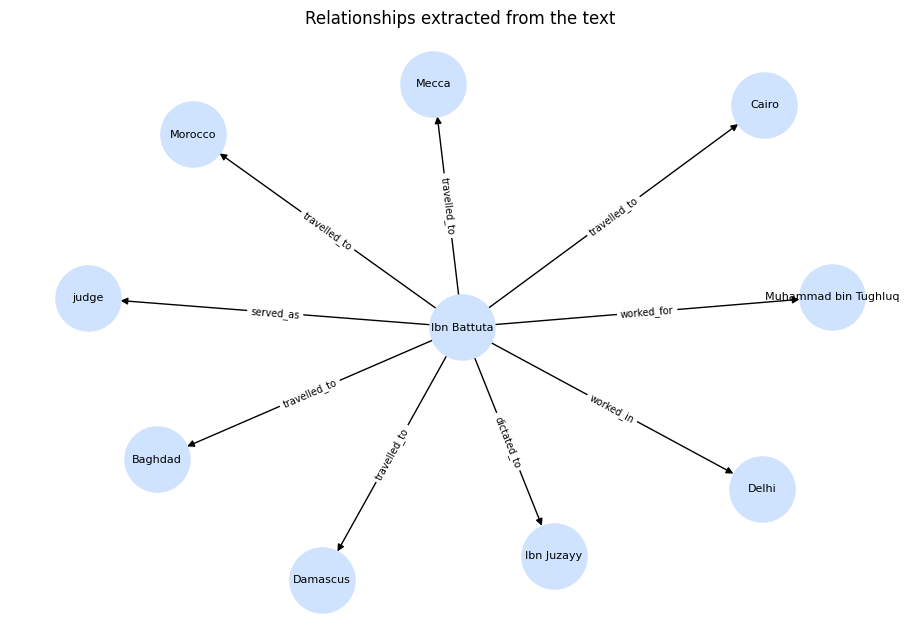

In [ ]:
import networkx as nx                # a library for building and analysing networks
import matplotlib.pyplot as plt       # a library for drawing figures

# Create an empty directed network (arrows have a direction)
G = nx.DiGraph()

# Add one arrow per triple (one per row of our table)
for _, row in df_rel_en.iterrows():
    G.add_edge(row["subject"], row["object"], label=row["relation"])

# Decide where to place each name on the page (seed=3 makes the layout repeatable)
positions = nx.spring_layout(G, seed=3, k=1.2)

# Draw the names, the circles and the arrows
plt.figure(figsize=(9, 6))
nx.draw(G, positions, with_labels=True, node_color="#cfe3ff", node_size=2200, font_size=8, arrows=True)

# Write the relation on each arrow
nx.draw_networkx_edge_labels(G, positions, edge_labels=nx.get_edge_attributes(G, "label"), font_size=7)
plt.title("Relationships extracted from the text")
plt.show()

---
## Checking the results

A language model can give answers that look convincing but are wrong. A simple and honest way to evaluate it for your own project:

1. **Label a sample by hand**, for example 30 passages, with the answers *you* consider correct.
2. **Run the model** on the same passages.
3. **Compare** the two and count how often they agree. Study the *mistakes*: they show where the model struggles with your material.
4. **Improve the prompt** (clearer definitions, an added example) and repeat.

## Good habits for research

- **Record** the exact prompt, the model name and the date together with your results. Models change over time.
- Ask for a **fixed output format** (such as JSON) so that results can be checked and counted.
- Treat the model as a **fast first pass**, not as ground truth. Verify important results.
- **Protect your data.** Do not send private, sensitive or restricted material to an online service unless your ethics approval and the data owner allow it. On the free Gemini tier, Google may use what you send to improve its products, so use public texts only.

## Exercises

1. Replace `english_text` and `arabic_text` with a passage from your own research. Which tasks work well, and which do not?
2. Add a new entity type (for example `EVENT`) to the NER prompt and run it again.
3. Add a fifth label to the sentiment prompt that fits your corpus (for example `IRONIC`).
4. Change the relation labels in the relationship prompt to ones that suit your project (for example `taught`, `studied_under`, `corresponded_with`).